In [1]:
import pandas as pd
df=pd.read_excel("Heart_Disease.xlsx")  
df.head()

,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
0,40,1,2,140,289,0,0,172,0,0.0,1,0
1,49,0,3,160,180,0,0,156,0,1.0,2,1
2,37,1,2,130,283,0,1,98,0,0.0,1,0
3,48,0,4,138,214,0,0,108,1,1.5,2,1
4,54,1,3,150,195,0,0,122,0,0.0,1,0


In [2]:
df.shape

(2518, 12)

In [3]:
# Check  duplicates
print("Duplicates before:", df.duplicated().sum())

# Remove duplicates
df = df.drop_duplicates()
print("Rows remaining:", df.shape[0])

Duplicates before: 1298
Rows remaining: 1220


In [4]:
# Missing Values
df.isnull().sum()

age                    0
sex                    0
chest pain type        0
resting bp s           0
cholesterol            0
fasting blood sugar    0
resting ecg            0
max heart rate         0
exercise angina        0
oldpeak                0
ST slope               0
target                 0
dtype: int64

# EDA

C:\Users\DELL\AppData\Local\Temp\ipykernel_12852\2247455200.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=df, palette='Set1')


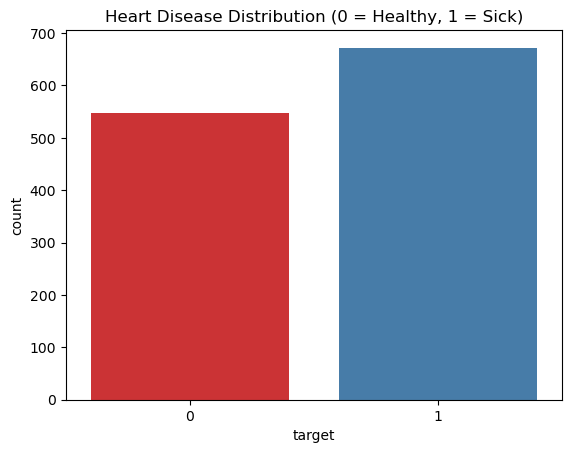

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='target', data=df, palette='Set1')
plt.title('Heart Disease Distribution (0 = Healthy, 1 = Sick)')
plt.show()

In [6]:
'''plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation between Medical Features')
plt.show()'''

"plt.figure(figsize=(12,8))\nsns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')\nplt.title('Correlation between Medical Features')\nplt.show()"

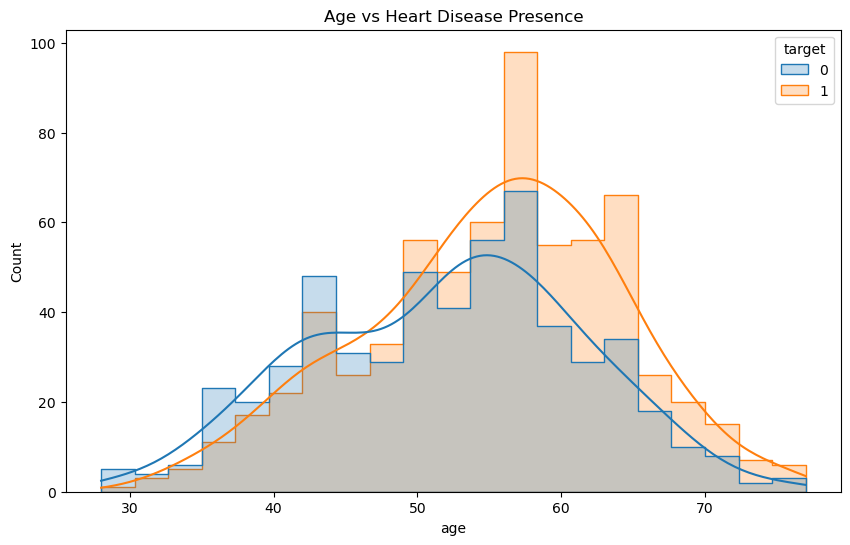

In [7]:
plt.figure(figsize=(10,6))
sns.histplot(data=df, x='age', hue='target', kde=True, element="step") #Kernel Density Estimate.adds smooth curved line
plt.title('Age vs Heart Disease Presence')
plt.show()

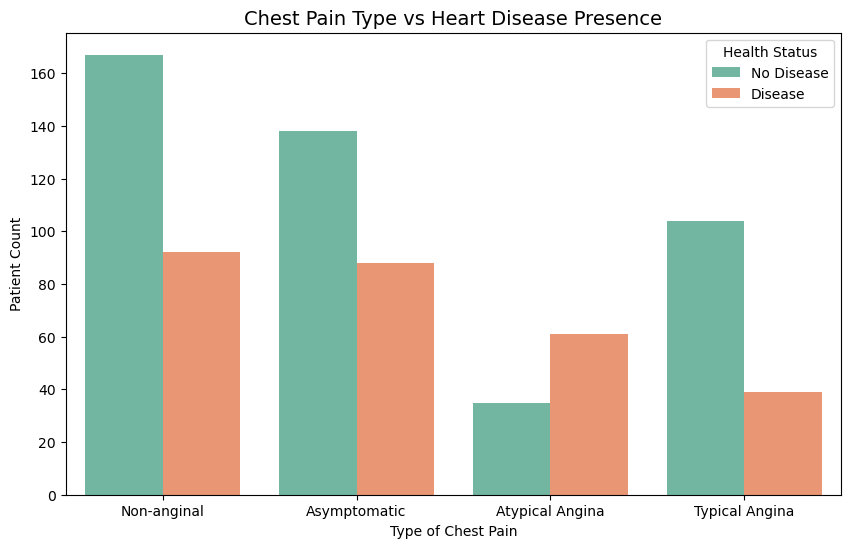

In [8]:
# Create a mapping dictionary 
cp_labels = {0: 'Typical Angina', 1: 'Atypical Angina', 2: 'Non-anginal', 3: 'Asymptomatic'}

plt.figure(figsize=(10, 6))
# We map the 'chest pain type' column to its string equivalents for the plot
sns.countplot(x=df['chest pain type'].map(cp_labels), hue='target', data=df, palette='Set2')

plt.title('Chest Pain Type vs Heart Disease Presence', fontsize=14)
plt.xlabel('Type of Chest Pain')
plt.ylabel('Patient Count')
plt.legend(title='Health Status', labels=['No Disease', 'Disease'])
plt.show()

# Preprocessing

In [9]:
df.columns

Index(['age', 'sex', 'chest pain type', 'resting bp s', 'cholesterol',
       'fasting blood sugar', 'resting ecg', 'max heart rate',
       'exercise angina', 'oldpeak', 'ST slope', 'target'],
      dtype='object')

In [10]:
df.head()

,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
0,40,1,2,140,289,0,0,172,0,0.0,1,0
1,49,0,3,160,180,0,0,156,0,1.0,2,1
2,37,1,2,130,283,0,1,98,0,0.0,1,0
3,48,0,4,138,214,0,0,108,1,1.5,2,1
4,54,1,3,150,195,0,0,122,0,0.0,1,0


In [11]:
x=df[['age', 'sex', 'chest pain type', 'resting bp s', 'cholesterol',
       'fasting blood sugar', 'resting ecg', 'max heart rate',
       'exercise angina', 'oldpeak', 'ST slope']]
y=df['target']

In [12]:
# StandardScaler
from sklearn.preprocessing import  StandardScaler
sc=StandardScaler()
df["age"]=sc.fit_transform(df[["age"]])
df['resting bp s']=sc.fit_transform(df[['resting bp s']])
df['cholesterol']=sc.fit_transform(df[['cholesterol']])
df['max heart rate']=sc.fit_transform(df[['max heart rate']])
df.head()

,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
0,-1.470729,1,2,0.426882,0.780890,0,0,1.259321,0,0.0,1,0
1,-0.507093,0,3,1.521452,-0.304888,0,0,0.630289,0,1.0,2,1
2,-1.791941,1,2,-0.120403,0.721122,0,1,-1.649953,0,0.0,1,0
3,-0.614164,0,4,0.317425,0.033795,0,0,-1.256808,1,1.5,2,1
4,0.028260,1,3,0.974167,-0.155469,0,0,-0.706404,0,0.0,1,0


In [13]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [14]:
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

In [15]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [16]:
model = XGBClassifier(max_depth=3, learning_rate=0.01, n_estimators=100, subsample=0.8, eval_metric='logloss') 

In [17]:
model.fit(x_train,y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [18]:
y_train_pred=model.predict(x_train)
y_test_predict=model.predict(x_test)

In [19]:
from sklearn.metrics import accuracy_score, confusion_matrix
print("training accuracy is",accuracy_score(y_train_pred,y_train))
print("Testing accuracy",accuracy_score(y_test_predict,y_test))

training accuracy is 0.8217213114754098
Testing accuracy 0.8155737704918032


In [20]:
print("Training confusion_matrix \n:",confusion_matrix(y_train_pred,y_train))
print("Testing confusion_matrix \n:",confusion_matrix(y_test_predict,y_test))

Training confusion_matrix 
: [[339  75]
 [ 99 463]]
Testing confusion_matrix 
: [[ 83  18]
 [ 27 116]]


In [21]:
from sklearn.metrics import recall_score
train_recall = recall_score(y_train, y_train_pred)
test_recall = recall_score(y_test, y_test_predict)
print(f"Training - Recall: {train_recall*100:.2f}")
print(f"Testing  - Recall: {test_recall*100:.2f}")


Training - Recall: 86.06
Testing  - Recall: 86.57


In [22]:
'''
from sklearn.metrics import recall_score, precision_score, f1_score, classification_report
#  Recall
train_recall = recall_score(y_train, y_train_pred)
test_recall = recall_score(y_test, y_test_predict)
#  Precision
train_precision = precision_score(y_train, y_train_pred)
test_precision = precision_score(y_test, y_test_predict)
#F1-Score
train_f1 = f1_score(y_train, y_train_pred)
test_f1 = f1_score(y_test, y_test_predict)
print(f"Training - Recall: {train_recall:.4f}, Precision: {train_precision:.4f}, F1: {train_f1:.4f}")
print(f"Testing  - Recall: {test_recall:.4f}, Precision: {test_precision:.4f}, F1: {test_f1:.4f}")
# classification_report 
print("\nFull Testing Report:")
print(classification_report(y_test, y_test_predict))
'''

'\nfrom sklearn.metrics import recall_score, precision_score, f1_score, classification_report\n#  Recall\ntrain_recall = recall_score(y_train, y_train_pred)\ntest_recall = recall_score(y_test, y_test_predict)\n#  Precision\ntrain_precision = precision_score(y_train, y_train_pred)\ntest_precision = precision_score(y_test, y_test_predict)\n#F1-Score\ntrain_f1 = f1_score(y_train, y_train_pred)\ntest_f1 = f1_score(y_test, y_test_predict)\nprint(f"Training - Recall: {train_recall:.4f}, Precision: {train_precision:.4f}, F1: {train_f1:.4f}")\nprint(f"Testing  - Recall: {test_recall:.4f}, Precision: {test_precision:.4f}, F1: {test_f1:.4f}")\n# classification_report \nprint("\nFull Testing Report:")\nprint(classification_report(y_test, y_test_predict))\n'

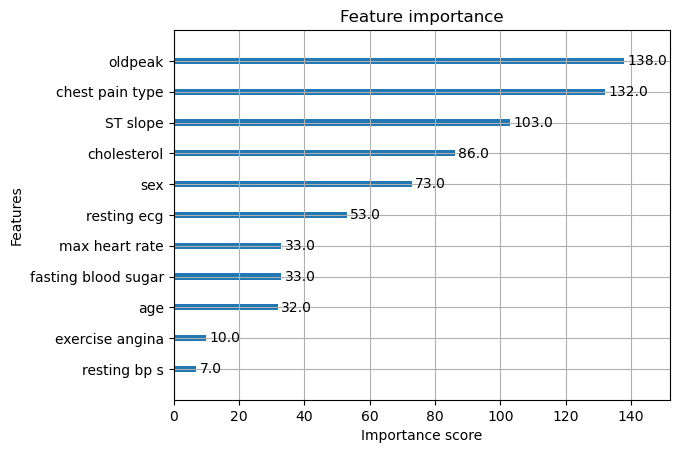

In [23]:
#Feature Importance
import matplotlib.pyplot as plt
from xgboost import plot_importance
plot_importance(model) #Horizontal Bar Chart
plt.show()

In [24]:
import pickle
pickle.dump(model,open("heart_pred_Model.pkl","wb"))